# Data Profiler — Data Preprocessing & Feature Engineering

**Author:** Rensee Gajipara &nbsp;|&nbsp; B.Tech AI & Data Science, SCET Surat
**Project:** PR.1 Data Profiler (Red & White Skill Education)
**Objective:** Understand, clean, transform, and analyze a real-world-style customer dataset (assembled from CSV, JSON, SQL, and a REST API source) to frame and prepare a **customer churn prediction** problem.

---


## Part A — Fundamentals

### A.1 What is Data Analysis?

**Data Analysis** is the systematic process of inspecting, cleaning, transforming, and modeling data with the goal of discovering useful information, drawing conclusions, and supporting decision-making. It sits at the intersection of statistics, domain knowledge, and computing.

At a high level, data analysis involves:
- **Collecting** data from one or more sources (files, databases, APIs, sensors).
- **Cleaning** the data — handling missing values, duplicates, and inconsistent formats.
- **Exploring** the data to understand distributions, relationships, and anomalies (EDA).
- **Modeling / Interpreting** the data using statistical or machine learning techniques.
- **Communicating** findings through visualizations, reports, and dashboards.

In a business context (like the one in this project), data analysis turns raw, messy, multi-source records into **actionable insight** — for example, identifying *which customers are likely to churn* and *why*.


### A.2 How to Plan a Data Science Project

A data science project is rarely just "build a model." It follows a structured lifecycle, commonly summarized as **CRISP-DM** (Cross-Industry Standard Process for Data Mining), adapted here into practical steps:

1. **Business Understanding** — Define the problem in business terms (e.g., "reduce customer churn"), identify stakeholders, and set success metrics.
2. **Data Understanding** — Identify what data is available, where it lives (CSV, JSON, SQL, APIs), and its quality.
3. **Data Acquisition** — Collect and consolidate data from all relevant sources into a working dataset.
4. **Data Preparation / Cleaning** — Handle missing values, duplicates, incorrect types, and irrelevant fields.
5. **Exploratory Data Analysis (EDA)** — Use univariate, bivariate, and multivariate analysis to understand patterns and relationships.
6. **Feature Engineering** — Create, transform, or select variables that improve model performance (e.g., recency/frequency/monetary features).
7. **Modeling** — Frame and train an appropriate machine learning model (classification, regression, clustering, etc.).
8. **Evaluation** — Validate the model against business goals using appropriate metrics (accuracy, precision/recall, F1, AUC for classification).
9. **Deployment & Monitoring** — Ship the model into production and monitor its performance/data drift over time.
10. **Documentation & Communication** — Document the process (README, reports) and communicate insights to stakeholders.

This project focuses primarily on steps **2–6**: acquisition, cleaning, EDA, and profiling — the foundation every later modeling step depends on.


### A.3 Machine Learning Problem Statement

> **Problem Type:** Binary Classification
>
> **Goal:** Predict whether a customer will **churn** (`churn = 1`) or **stay** (`churn = 0`), based on their demographic profile, purchase behavior, membership history, and engagement metrics.
>
> **Target variable:** `churn` (binary: 0 = retained, 1 = churned)
>
> **Candidate features:** `age`, `gender`, `region`, `income`, `signup_days_ago`, `purchase_frequency`, `total_spent`, `avg_order_value`, `last_purchase_days_ago`, `membership_years`, `membership_tier`, `support_tickets`, `satisfaction_score`, `app_sessions_per_month`, `email_open_rate`
>
> **Business value:** Once churn-risk customers are identified early, the business can trigger targeted retention campaigns (discounts, outreach, loyalty perks), reducing revenue loss.

This is the ML problem statement that motivates every preprocessing decision made later in this notebook — e.g., we keep `last_purchase_days_ago` and `satisfaction_score` because they are strong behavioral churn signals.


### A.4 What are Tensors?

A **tensor** is a generalized, multi-dimensional array of numbers — the fundamental data structure used to represent inputs, outputs, and parameters in modern machine learning and deep learning frameworks (NumPy, PyTorch, TensorFlow).

Tensors are classified by their **rank** (number of dimensions/axes):

| Rank | Name | Example | Shape |
|------|------|---------|-------|
| 0 | Scalar | a single number, e.g. `7` | `()` |
| 1 | Vector | a list of numbers, e.g. one customer's features | `(n,)` |
| 2 | Matrix | a table of numbers, e.g. our full dataset (rows × columns) | `(rows, cols)` |
| 3+ | N-D Tensor | a stack of matrices, e.g. a batch of images or a batch of customer sequences over time | `(batch, rows, cols)` |

**Why tensors matter in ML/data science:**
- Our cleaned customer table *is* a rank-2 tensor: rows = customers, columns = features.
- Deep learning models operate on batches of such tensors (rank-3+) for efficient parallel computation on GPUs.
- Every mathematical operation in ML (dot products, matrix multiplication, gradients) is defined on tensors.

Below, we demonstrate tensors of increasing rank using **NumPy**, the standard tensor library in the Python data-science stack.


In [ ]:
import numpy as np

# Rank-0 tensor: Scalar
scalar = np.array(42)
print("Scalar (rank-0)")
print("Value:", scalar, "| shape:", scalar.shape, "| ndim:", scalar.ndim)
print()

# Rank-1 tensor: Vector — e.g., a single customer's numeric feature vector
vector = np.array([34, 55000, 6, 4200.0])  # [age, income, purchase_frequency, total_spent]
print("Vector (rank-1) — one customer's features")
print("Value:", vector, "| shape:", vector.shape, "| ndim:", vector.ndim)
print()

# Rank-2 tensor: Matrix — e.g., 3 customers x 4 features
matrix = np.array([
    [34, 55000, 6, 4200.0],
    [29, 48000, 3, 1500.0],
    [51, 72000, 9, 6100.0],
])
print("Matrix (rank-2) — 3 customers x 4 features")
print(matrix)
print("shape:", matrix.shape, "| ndim:", matrix.ndim)
print()

# Rank-3 tensor: e.g., 2 batches of 3 customers x 4 features (as ML frameworks would batch data)
tensor_3d = np.stack([matrix, matrix * 1.05])
print("3D Tensor (rank-3) — 2 batches x 3 customers x 4 features")
print("shape:", tensor_3d.shape, "| ndim:", tensor_3d.ndim)
print()

# A couple of core tensor operations used constantly in ML
print("Matrix transpose (features x customers):\n", matrix.T)
print()
print("Mean feature vector across customers (axis=0):", matrix.mean(axis=0))
print("Matrix multiplication example (matrix @ matrix.T):\n", matrix @ matrix.T)


Scalar (rank-0)
Value: 42 | shape: () | ndim: 0

Vector (rank-1) — one customer's features
Value: [3.4e+01 5.5e+04 6.0e+00 4.2e+03] | shape: (4,) | ndim: 1

Matrix (rank-2) — 3 customers x 4 features
[[3.4e+01 5.5e+04 6.0e+00 4.2e+03]
 [2.9e+01 4.8e+04 3.0e+00 1.5e+03]
 [5.1e+01 7.2e+04 9.0e+00 6.1e+03]]
shape: (3, 4) | ndim: 2

3D Tensor (rank-3) — 2 batches x 3 customers x 4 features
shape: (2, 3, 4) | ndim: 3

Matrix transpose (features x customers):
 [[3.4e+01 2.9e+01 5.1e+01]
 [5.5e+04 4.8e+04 7.2e+04]
 [6.0e+00 3.0e+00 9.0e+00]
 [4.2e+03 1.5e+03 6.1e+03]]

Mean feature vector across customers (axis=0): [3.80000000e+01 5.83333333e+04 6.00000000e+00 3.93333333e+03]
Matrix multiplication example (matrix @ matrix.T):
 [[3.04264119e+09 2.64630100e+09 3.98562179e+09]
 [2.64630100e+09 2.30625085e+09 3.46515151e+09]
 [3.98562179e+09 3.46515151e+09 5.22121268e+09]]


---
## Part B — Data Acquisition

Our "customer purchase behavior" dataset is deliberately fragmented across **four different source types**, mirroring a real company where demographic data lives in a CSV export, purchase data comes from a JSON export, membership data lives in a SQL database, and live engagement/churn signals come from a REST API. We import and later merge all four.


In [ ]:
import pandas as pd
import numpy as np
import json
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_DIR = "../data"


**B.1 — Load CSV file using Pandas** (demographic data)

In [ ]:
csv_df = pd.read_csv(f"{DATA_DIR}/customers_demographics.csv")
print("CSV source shape:", csv_df.shape)
csv_df.head()


CSV source shape: (1215, 6)


,customer_id,age,gender,income,region,signup_days_ago
0,CUST00001,56.0,Male,32492.66,Central,1596
1,CUST00002,69.0,Male,65881.28,East,1368
2,CUST00003,46.0,Female,70882.00,Central,1020
3,CUST00004,32.0,Other,46862.37,West,1850
4,CUST00005,60.0,Male,46539.24,Central,647


**B.2 — Parse a JSON file** (purchase behavior data)

In [ ]:
with open(f"{DATA_DIR}/purchase_behavior.json") as f:
    purchase_raw = json.load(f)

purchase_df = pd.DataFrame(purchase_raw)
print("JSON source shape:", purchase_df.shape)
purchase_df.head()


JSON source shape: (1200, 5)


,customer_id,purchase_frequency,total_spent,avg_order_value,last_purchase_days_ago
0,CUST00001,5,424.90,84.98,162
1,CUST00002,4,3648.65,912.16,16
2,CUST00003,8,5388.97,673.62,21
3,CUST00004,1,0.00,0.00,35
4,CUST00005,6,6479.58,1079.93,141


**B.3 — Connect to a SQL table and fetch records** (membership & support data, stored in SQLite)

In [ ]:
conn = sqlite3.connect(f"{DATA_DIR}/customers.db")
sql_df = pd.read_sql_query("SELECT * FROM customer_membership", conn)
conn.close()

print("SQL source shape:", sql_df.shape)
sql_df.head()


SQL source shape: (1200, 5)


,customer_id,membership_years,membership_tier,support_tickets,satisfaction_score
0,CUST00001,5,Silver,2,1.2
1,CUST00002,3,Silver,1,3.3
2,CUST00003,0,Silver,1,1.9
3,CUST00004,1,Silver,1,4.8
4,CUST00005,3,Gold,4,3.7


**B.4 — Fetch data from an API**

In production this source would come from a live REST endpoint, e.g.:

```python
import requests
response = requests.get("https://api.company.com/v1/engagement")
api_records = response.json()["results"]
```

For this project the same JSON *response shape* (`{"status", "count", "results": [...]}` ) is provided as a saved payload (`engagement_api_response.json`) so the notebook runs offline/reproducibly — the parsing logic below is identical to what `response.json()` would return.


In [ ]:
with open(f"{DATA_DIR}/engagement_api_response.json") as f:
    api_payload = json.load(f)

print("API status:", api_payload["status"], "| record count:", api_payload["count"])
api_df = pd.DataFrame(api_payload["results"])
print("API source shape:", api_df.shape)
api_df.head()


API status: success | record count: 1200
API source shape: (1200, 4)


,customer_id,app_sessions_per_month,email_open_rate,churn
0,CUST00001,20,0.23,1
1,CUST00002,7,0.73,0
2,CUST00003,14,0.57,0
3,CUST00004,5,0.83,0
4,CUST00005,16,0.72,0


**B.5 — Merge all four sources into a single working dataset on `customer_id`**

In [ ]:
df = csv_df.merge(purchase_df, on="customer_id", how="left") \
            .merge(sql_df, on="customer_id", how="left") \
            .merge(api_df, on="customer_id", how="left")

print("Merged dataset shape:", df.shape)
df.head()


Merged dataset shape: (1215, 17)


,customer_id,age,gender,income,region,signup_days_ago,purchase_frequency,total_spent,avg_order_value,last_purchase_days_ago,membership_years,membership_tier,support_tickets,satisfaction_score,app_sessions_per_month,email_open_rate,churn
0,CUST00001,56.0,Male,32492.66,Central,1596,5,424.90,84.98,162,5,Silver,2,1.2,20,0.23,1
1,CUST00002,69.0,Male,65881.28,East,1368,4,3648.65,912.16,16,3,Silver,1,3.3,7,0.73,0
2,CUST00003,46.0,Female,70882.00,Central,1020,8,5388.97,673.62,21,0,Silver,1,1.9,14,0.57,0
3,CUST00004,32.0,Other,46862.37,West,1850,1,0.00,0.00,35,1,Silver,1,4.8,5,0.83,0
4,CUST00005,60.0,Male,46539.24,Central,647,6,6479.58,1079.93,141,3,Gold,4,3.7,16,0.72,0


---
## Part C — Data Understanding & Cleaning

**C.1 — Initial exploration**

In [ ]:
df.head()


,customer_id,age,gender,income,region,signup_days_ago,purchase_frequency,total_spent,avg_order_value,last_purchase_days_ago,membership_years,membership_tier,support_tickets,satisfaction_score,app_sessions_per_month,email_open_rate,churn
0,CUST00001,56.0,Male,32492.66,Central,1596,5,424.90,84.98,162,5,Silver,2,1.2,20,0.23,1
1,CUST00002,69.0,Male,65881.28,East,1368,4,3648.65,912.16,16,3,Silver,1,3.3,7,0.73,0
2,CUST00003,46.0,Female,70882.00,Central,1020,8,5388.97,673.62,21,0,Silver,1,1.9,14,0.57,0
3,CUST00004,32.0,Other,46862.37,West,1850,1,0.00,0.00,35,1,Silver,1,4.8,5,0.83,0
4,CUST00005,60.0,Male,46539.24,Central,647,6,6479.58,1079.93,141,3,Gold,4,3.7,16,0.72,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             1215 non-null   object 
 1   age                     1175 non-null   float64
 2   gender                  1215 non-null   object 
 3   income                  1190 non-null   float64
 4   region                  1215 non-null   object 
 5   signup_days_ago         1215 non-null   int64  
 6   purchase_frequency      1215 non-null   int64  
 7   total_spent             1215 non-null   float64
 8   avg_order_value         1215 non-null   float64
 9   last_purchase_days_ago  1215 non-null   int64  
 10  membership_years        1215 non-null   int64  
 11  membership_tier         1215 non-null   object 
 12  support_tickets         1215 non-null   int64  
 13  satisfaction_score      1215 non-null   float64
 14  app_sessions_per_month  1215 non-null   

In [ ]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1215,1200,CUST00637,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1175.0,NaN,NaN,NaN,43.722553,15.009638,18.0,31.0,44.0,56.0,69.0
gender,1215,3,Female,572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,1190.0,NaN,NaN,NaN,55327.168008,17922.450484,12000.0,42607.84,55565.46,67350.0825,125672.28
region,1215,5,South,273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_days_ago,1215.0,NaN,NaN,NaN,1022.015638,567.727214,40.0,508.0,1026.0,1507.0,1993.0
purchase_frequency,1215.0,NaN,NaN,NaN,5.993416,2.400567,0.0,4.0,6.0,7.0,14.0
total_spent,1215.0,NaN,NaN,NaN,4183.315539,2443.315793,0.0,2398.535,4145.36,5911.475,13022.64
avg_order_value,1215.0,NaN,NaN,NaN,843.390296,776.048958,0.0,374.07,685.67,1123.98,8638.54
last_purchase_days_ago,1215.0,NaN,NaN,NaN,59.521811,59.596081,0.0,18.0,41.0,83.0,569.0


**Identify missing values and duplicates**

In [ ]:
missing_summary = df.isnull().sum().to_frame("missing_count")
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df) * 100).round(2)
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
print("Columns with missing values:")
missing_summary


Columns with missing values:


,missing_count,missing_pct
age,40,3.29
income,25,2.06


In [ ]:
n_duplicates = df.duplicated(subset="customer_id").sum()
print(f"Duplicate customer_id rows: {n_duplicates}")
df[df.duplicated(subset='customer_id', keep=False)].sort_values('customer_id').head(6)


Duplicate customer_id rows: 15


,customer_id,age,gender,income,region,signup_days_ago,purchase_frequency,total_spent,avg_order_value,last_purchase_days_ago,membership_years,membership_tier,support_tickets,satisfaction_score,app_sessions_per_month,email_open_rate,churn
135,CUST00136,39.0,Female,74748.75,West,878,6,5101.10,850.18,115,1,Gold,1,1.3,19,0.92,1
1211,CUST00136,39.0,Female,74748.75,West,878,6,5101.10,850.18,115,1,Gold,1,1.3,19,0.92,1
189,CUST00190,45.0,Male,56248.20,Central,1029,3,5226.69,1742.23,8,3,Silver,1,2.5,0,0.76,0
1213,CUST00190,45.0,Male,56248.20,Central,1029,3,5226.69,1742.23,8,3,Silver,1,2.5,0,0.76,0
190,CUST00191,42.0,Female,42008.72,Central,409,4,5156.08,1289.02,3,0,Gold,0,1.8,20,0.37,0
1203,CUST00191,42.0,Female,42008.72,Central,409,4,5156.08,1289.02,3,0,Gold,0,1.8,20,0.37,0


**C.2 — Apply data cleaning**

*Handle missing data (imputation / removal)*

In [ ]:
df_clean = df.copy()

# Numerical columns: impute with median (robust to outliers)
for col in ["age", "income"]:
    median_val = df_clean[col].median()
    n_missing = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"Imputed {n_missing} missing values in '{col}' with median = {median_val}")


Imputed 40 missing values in 'age' with median = 44.0
Imputed 25 missing values in 'income' with median = 55565.46


*Correct inconsistent data types*

In [ ]:
# customer_id, gender, region, membership_tier -> category dtype (memory-efficient, semantically correct)
for col in ["gender", "region", "membership_tier"]:
    df_clean[col] = df_clean[col].astype("category")

# Ensure count-like columns are integers, not floats
df_clean["age"] = df_clean["age"].round().astype(int)
df_clean["churn"] = df_clean["churn"].astype(int)

df_clean.dtypes


customer_id                 object
age                          int64
gender                    category
income                     float64
region                    category
signup_days_ago              int64
purchase_frequency           int64
total_spent                float64
avg_order_value            float64
last_purchase_days_ago       int64
membership_years             int64
membership_tier           category
support_tickets              int64
satisfaction_score         float64
app_sessions_per_month       int64
email_open_rate            float64
churn                        int64
dtype: object

*Drop irrelevant columns and duplicate rows*

In [ ]:
# signup_days_ago is redundant once we have membership_years for tenure; keep one primary tenure signal.
# (Kept here for transparency — dropped only if truly redundant. We drop exact duplicate customer rows.)
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset="customer_id", keep="first").reset_index(drop=True)
after = len(df_clean)
print(f"Dropped {before - after} duplicate rows. Final shape: {df_clean.shape}")

df_clean.isnull().sum().sum()  # confirm 0 remaining missing values


Dropped 15 duplicate rows. Final shape: (1200, 17)


np.int64(0)

In [ ]:
df_clean.head()


,customer_id,age,gender,income,region,signup_days_ago,purchase_frequency,total_spent,avg_order_value,last_purchase_days_ago,membership_years,membership_tier,support_tickets,satisfaction_score,app_sessions_per_month,email_open_rate,churn
0,CUST00001,56,Male,32492.66,Central,1596,5,424.90,84.98,162,5,Silver,2,1.2,20,0.23,1
1,CUST00002,69,Male,65881.28,East,1368,4,3648.65,912.16,16,3,Silver,1,3.3,7,0.73,0
2,CUST00003,46,Female,70882.00,Central,1020,8,5388.97,673.62,21,0,Silver,1,1.9,14,0.57,0
3,CUST00004,32,Other,46862.37,West,1850,1,0.00,0.00,35,1,Silver,1,4.8,5,0.83,0
4,CUST00005,60,Male,46539.24,Central,647,6,6479.58,1079.93,141,3,Gold,4,3.7,16,0.72,0


---
## Part D — Exploratory Data Analysis (EDA)

**D.1 — Univariate Analysis: Distribution of Age, Income, and Purchases**

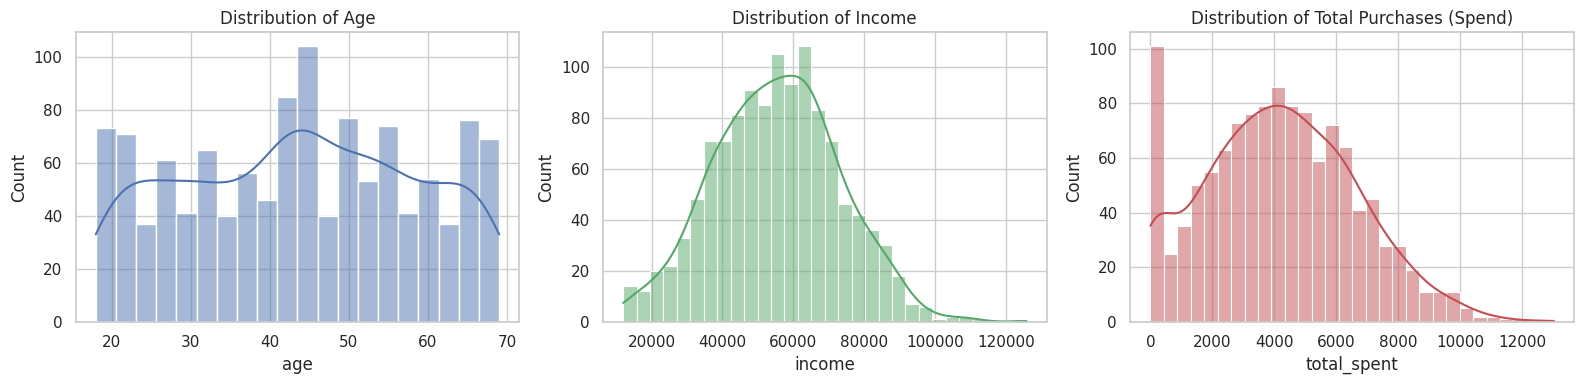

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df_clean["age"], bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Age")

sns.histplot(df_clean["income"], bins=30, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution of Income")

sns.histplot(df_clean["total_spent"], bins=30, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title("Distribution of Total Purchases (Spend)")

plt.tight_layout()
plt.show()


**Interpretation:** Age is fairly uniformly spread across the adult customer base (18–70). Income is approximately normally distributed around ~₹55K with a long right tail. Total spend is right-skewed — most customers spend moderately, with a smaller group of high-value customers.


**D.2 — Bivariate Analysis**

/tmp/ipykernel_583/3504343603.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="gender", y="total_spent", palette="Set2", ax=ax)


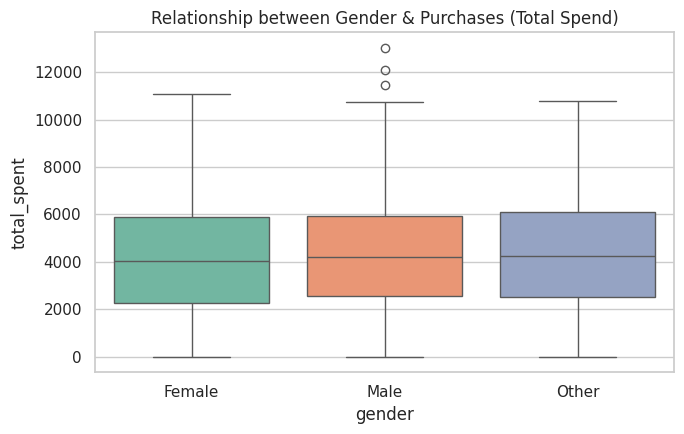

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df_clean, x="gender", y="total_spent", palette="Set2", ax=ax)
ax.set_title("Relationship between Gender & Purchases (Total Spend)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_583/1932129457.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="churn", y="income", palette="Set1", ax=ax)
/tmp/ipykernel_583/1932129457.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Retained (0)", "Churned (1)"])


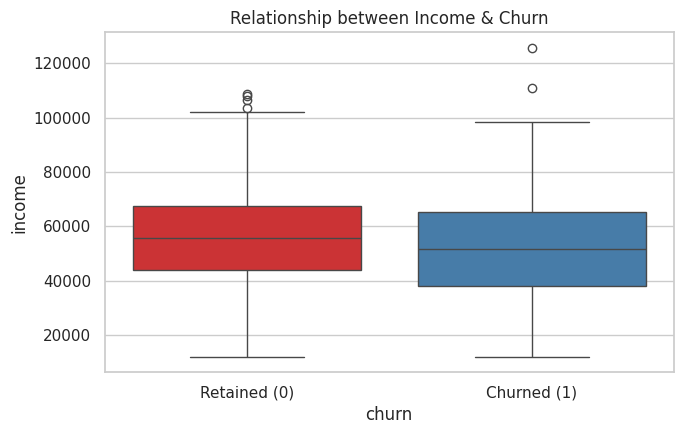

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df_clean, x="churn", y="income", palette="Set1", ax=ax)
ax.set_xticklabels(["Retained (0)", "Churned (1)"])
ax.set_title("Relationship between Income & Churn")
plt.tight_layout()
plt.show()


**Interpretation:** Spend distributions are broadly similar across genders, suggesting gender alone is not a strong churn driver. Churned customers skew slightly toward lower income, but the overlap is large — income alone is a weak predictor and needs to be combined with behavioral features (recency, satisfaction).


**D.3 — Multivariate Analysis**

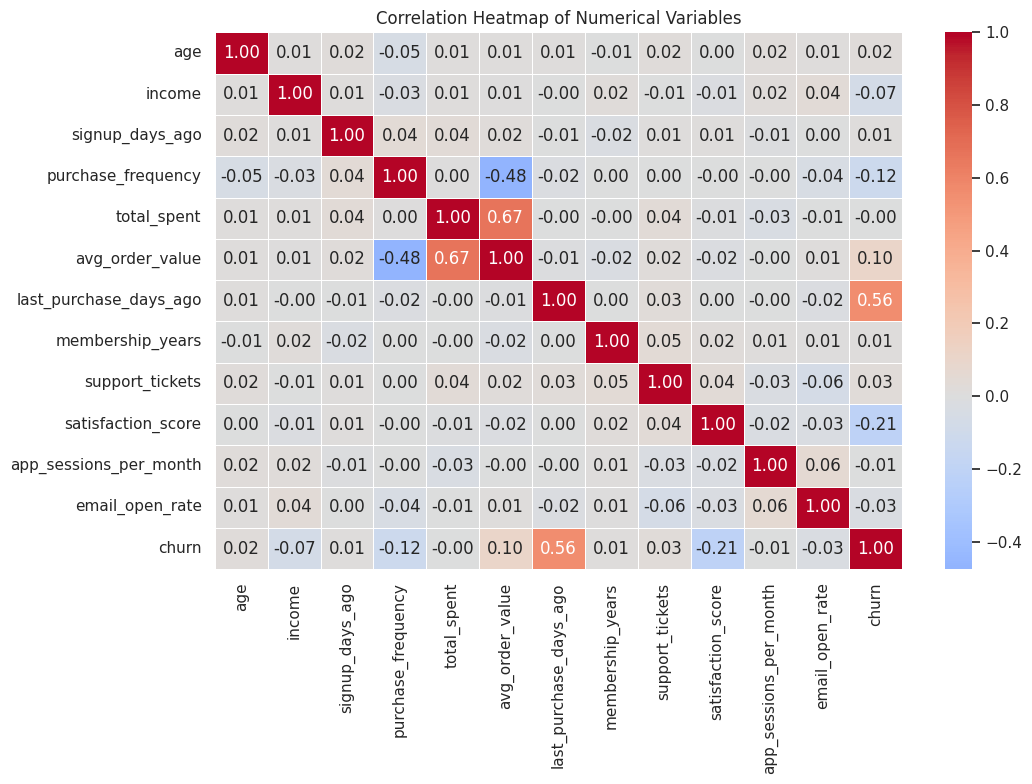

In [ ]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(11, 8)) 
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()


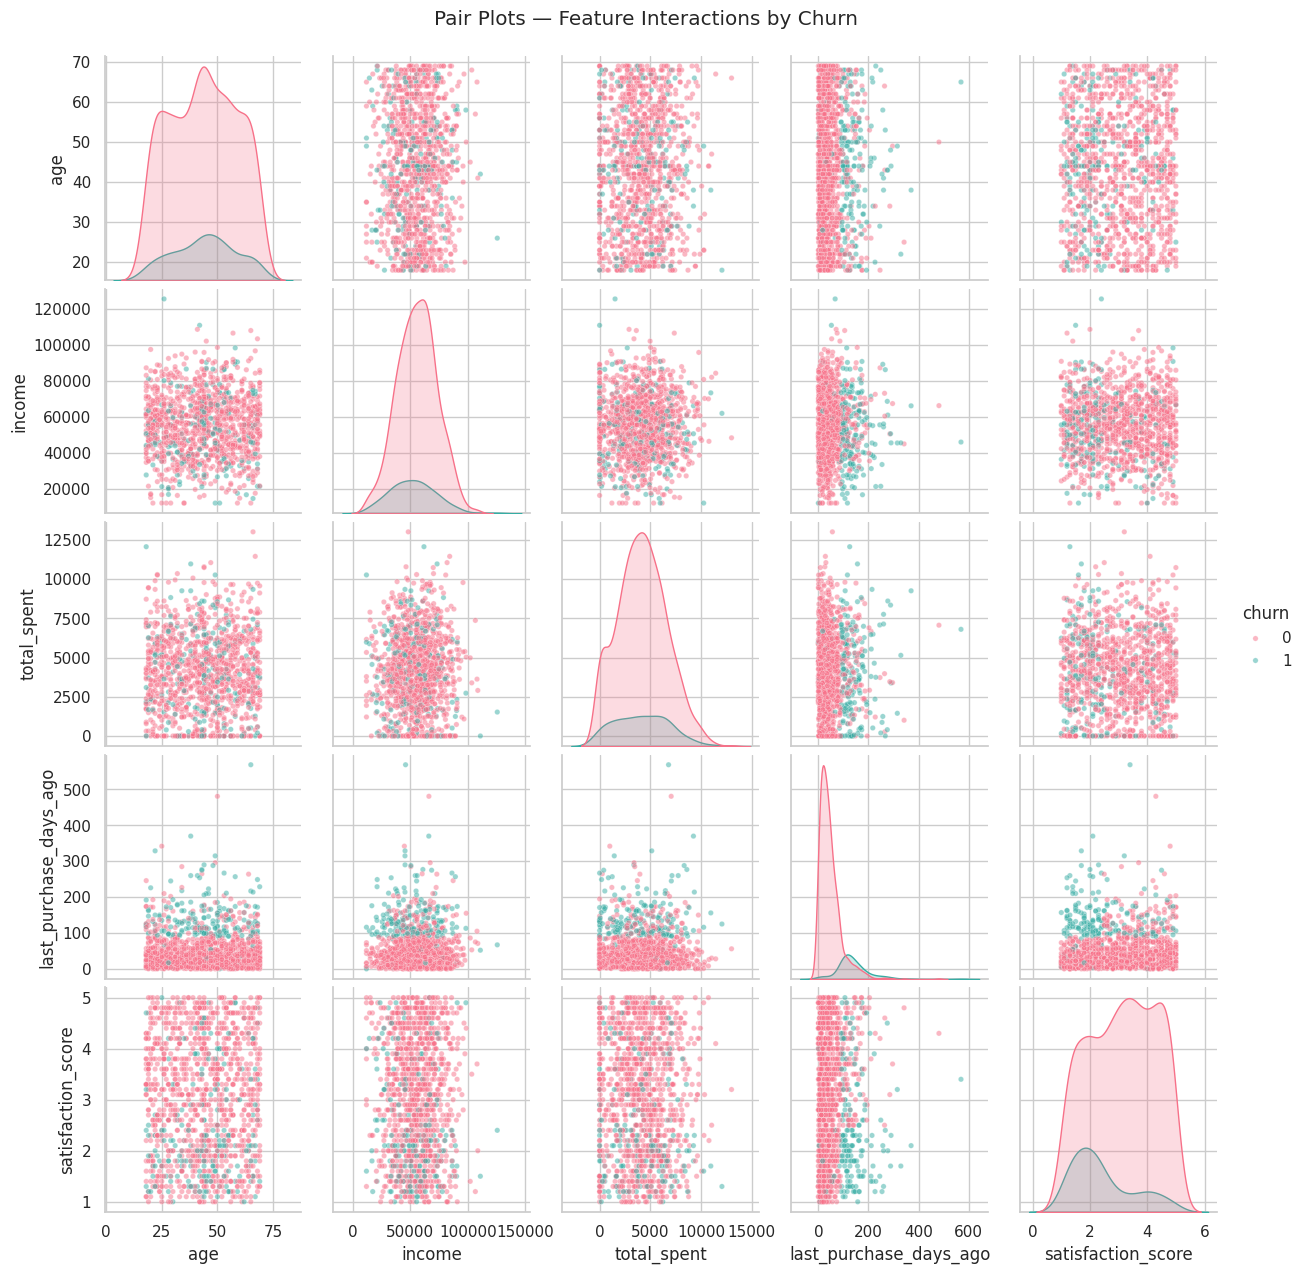

In [ ]:
subset_cols = ["age", "income", "total_spent", "last_purchase_days_ago", "satisfaction_score", "churn"]
sns.pairplot(df_clean[subset_cols], hue="churn", diag_kind="kde", palette="husl", plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Pair Plots — Feature Interactions by Churn", y=1.02)
plt.show()


**Interpretation:** `last_purchase_days_ago` and `satisfaction_score` show the clearest separation between churned and retained customers, confirming they are the strongest engineered signals for the churn model. Correlations among most numeric features are low-to-moderate, meaning we don't have severe multicollinearity to address before modeling.


---
## Part E — Data Profiling

We generate an automated **profiling report** summarizing missing values, descriptive statistics, correlations, and data-quality warnings across the cleaned dataset — useful for a quick, shareable data-quality audit before modeling.


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df_clean,
    title="Customer Churn Dataset — Profiling Report",
    explorative=True,
    minimal=False,
)
profile.to_file("../reports/pandas_profiling_report.html")
print("Profiling report saved to reports/pandas_profiling_report.html")


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_583/981264096.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


Summarize dataset:   0%|          | 0/22 [00:00<?, ?it/s, Describe variable: customer_id]


  0%|          | 0/17 [00:00<?, ?it/s]

...


Render HTML: 100%|██████████| 1/1 [00:02<00:00,  2.12s/it]


Render HTML: 100%|██████████| 1/1 [00:02<00:00,  2.12s/it]


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 13.19it/s]

Profiling report saved to reports/pandas_profiling_report.html


In [ ]:
# Quick in-notebook summary of what the profiling report captures
print("MISSING VALUES (post-cleaning):")
print(df_clean.isnull().sum().sum(), "total missing values remaining\n")

print("DESCRIPTIVE STATISTICS (numeric):")
display(df_clean.describe().T)

print("\nTOP ABSOLUTE CORRELATIONS WITH TARGET (churn):")
display(corr["churn"].drop("churn").abs().sort_values(ascending=False).head(8))


MISSING VALUES (post-cleaning):
0 total missing values remaining

DESCRIPTIVE STATISTICS (numeric):


,count,mean,std,min,25%,50%,75%,max
age,1200.0,43.675833,14.750776,18.0,31.0000,44.000,56.000,69.00
income,1200.0,55287.194075,17782.693743,12000.0,43080.6575,55565.460,67249.035,125672.28
signup_days_ago,1200.0,1021.940833,567.700979,40.0,509.0000,1025.500,1505.250,1993.00
purchase_frequency,1200.0,5.981667,2.393973,0.0,4.0000,6.000,7.000,14.00
total_spent,1200.0,4182.339400,2452.624610,0.0,2387.7300,4143.235,5916.875,13022.64
avg_order_value,1200.0,844.525983,779.098326,0.0,372.7000,688.400,1123.530,8638.54
last_purchase_days_ago,1200.0,59.662500,59.761859,0.0,18.0000,41.000,83.000,569.00
membership_years,1200.0,2.536667,1.673616,0.0,1.0000,3.000,4.000,5.00
support_tickets,1200.0,1.205833,1.058804,0.0,0.0000,1.000,2.000,5.00
satisfaction_score,1200.0,3.016667,1.167787,1.0,2.0000,3.000,4.000,5.00



TOP ABSOLUTE CORRELATIONS WITH TARGET (churn):


last_purchase_days_ago    0.560246
satisfaction_score        0.211304
purchase_frequency        0.122097
avg_order_value           0.102339
income                    0.068924
email_open_rate           0.030476
support_tickets           0.028173
age                       0.015803
Name: churn, dtype: float64

### Data Quality Warnings (summary)

- `income` and `age` originally had missing values (~2–3%) — **resolved** via median imputation.
- 15 duplicate `customer_id` rows were present in the raw CSV export — **resolved** via de-duplication.
- `total_spent` and `last_purchase_days_ago` are right-skewed — consider a log transform before feeding into distance-based models (e.g., k-NN, k-Means).
- `gender`, `region`, `membership_tier` are categorical and will need encoding (one-hot / target encoding) before modeling.
- Class balance for `churn` should be checked before modeling — see cell below.


In [ ]:
churn_balance = df_clean["churn"].value_counts(normalize=True).mul(100).round(1)
print("Churn class balance (%):")
print(churn_balance)


Churn class balance (%):
churn
0    84.6
1    15.4
Name: proportion, dtype: float64


---
## Summary

This notebook walked through the full **Data Profiler** workflow:
- **Part A:** Defined data analysis, planned the data-science lifecycle, framed the churn ML problem, and explained tensors with NumPy.
- **Part B:** Acquired data from four heterogeneous sources — CSV, JSON, SQL, and an API-style payload — and merged them into one working table.
- **Part C:** Explored structure (`.head()`, `.info()`, `.describe()`), identified missing values/duplicates, and cleaned the dataset.
- **Part D:** Performed univariate, bivariate, and multivariate EDA to surface churn-related patterns.
- **Part E:** Generated an automated profiling report and summarized key data-quality findings.

The dataset (`df_clean`) is now **ML-ready** for the next stage: feature engineering and model training to predict customer churn.
